Forecast Horizon=1 ~ 1st Best 

GPU: CPU


[*********************100%***********************]  1 of 1 completed


Removed 54 rows corresponding to ex-dividend and earnings dates.
Null values in each column:
 Price        Ticker
Close        BK        0
High         BK        0
Low          BK        0
Open         BK        0
Volume       BK        0
20MA                   0
50MA                   0
RSI                    0
12EMA                  0
26EMA                  0
MACD                   0
Signal_Line            0
Upper_BB               0
Lower_BB               0
CCI                    0
ATR                    0
Williams_%R            0
OBV                    0
dtype: int64
Does the dataset contain any null values? False

=== LSTM Model Architecture ===
LSTMModel(
  (lstm): LSTM(7, 64, batch_first=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Running for indicators: ['20MA', '50MA', 'RSI', 'Upper_BB', 'Lower_BB', 'Williams_%R'], Window: 60, Forecast: 1
Early stopping at epoch 48

=== Train Metrics ===
RMSE: 0.9678, MAE: 0.7067

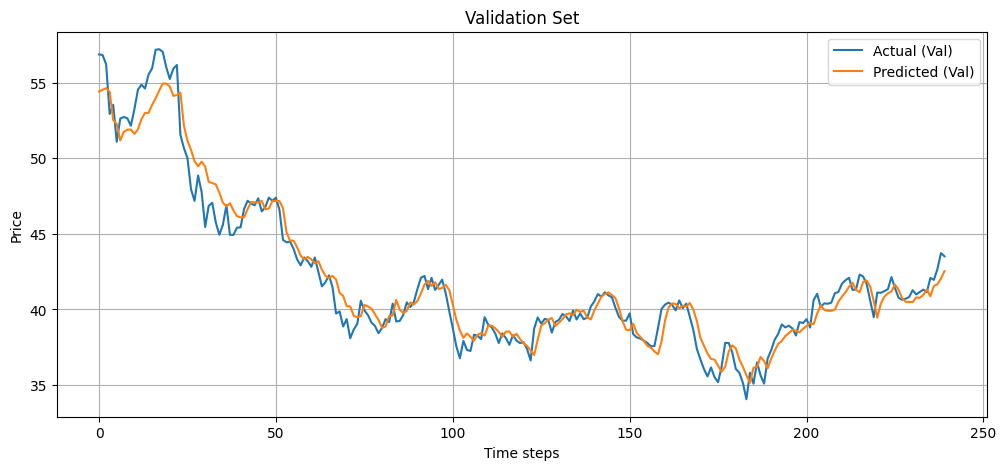

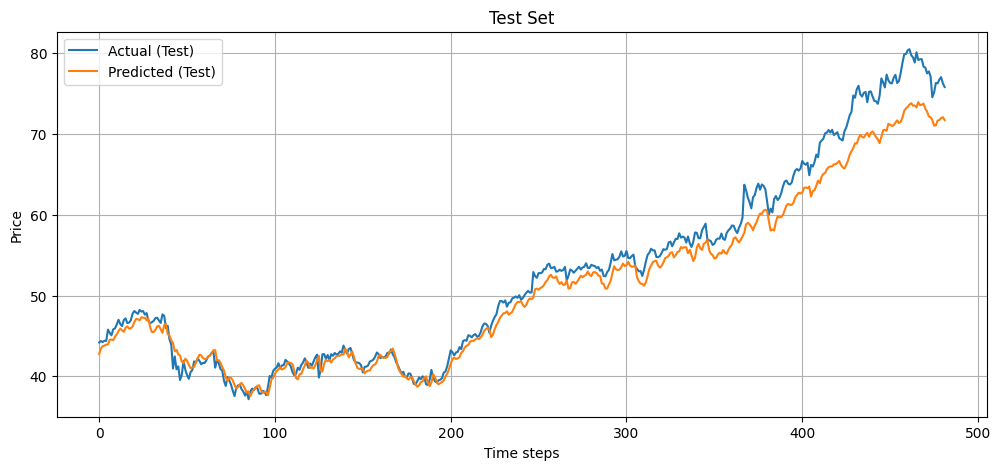

In [2]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

if "__file__" in globals():
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..', '..'))
else:
    project_root = os.path.abspath(os.path.join("..", ".."))
sys.path.append(project_root)

from ReusableFunctions.DataPreprocessing import DataPreprocessing
from ReusableFunctions.EvaluationMetrics import EvaluationMetrics as EM
from reproducibility_settings import set_global_seed

# -------------------
# Reproducibility & device
# -------------------
set_global_seed(seed=42, framework='torch')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# -------------------
# LSTM Model 
# -------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_rate):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,       # 🔹 single layer only
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        out, _ = self.lstm(x)      # (batch, seq_len, hidden_size)
        out = out[:, -1, :]        # take last timestep
        out = self.dropout(out)
        return self.fc(out)        # (batch, 1)

# -------------------
# Train & evaluate
# -------------------
def train_and_evaluate_model(model, train_loader, val_data, test_data, optimizer, criterion, scaler_y, forecast_window, epochs, patience=0.2):
    actual_patience = int(patience * epochs) if isinstance(patience, float) else patience

    # Convert datasets (keep shape: batch, seq_len, features)
    X_val_tensor = torch.tensor(val_data[0], dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(val_data[1], dtype=torch.float32).to(device)

    X_test_tensor = torch.tensor(test_data[0], dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(test_data[1], dtype=torch.float32).to(device)

    full_train_x = torch.cat([xb for xb, _ in train_loader]).to(device)
    full_train_y = torch.cat([yb for _, yb in train_loader]).to(device)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb).squeeze(), yb.squeeze())
            loss.backward()
            optimizer.step()

        # Validation loss
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_tensor).squeeze()
            val_loss = criterion(val_preds, y_val_tensor.squeeze()).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= actual_patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if best_state:
        model.load_state_dict(best_state)

    # ---- Predictions ----
    model.eval()
    with torch.no_grad():
        # Train metrics
        train_preds_scaled = model(full_train_x).squeeze().cpu().numpy()
        train_preds_unscaled = scaler_y.inverse_transform(train_preds_scaled.reshape(-1, 1))
        y_train_unscaled = scaler_y.inverse_transform(full_train_y.cpu().numpy().reshape(-1, 1))

        # Validation metrics
        val_preds_scaled = model(X_val_tensor).squeeze().cpu().numpy()
        val_preds_unscaled = scaler_y.inverse_transform(val_preds_scaled.reshape(-1, 1))
        y_val_unscaled = scaler_y.inverse_transform(val_data[1].reshape(-1, 1))

        # Test metrics
        test_preds_scaled = model(X_test_tensor).squeeze().cpu().numpy()
        test_preds_unscaled = scaler_y.inverse_transform(test_preds_scaled.reshape(-1, 1))
        y_test_unscaled = scaler_y.inverse_transform(test_data[1].reshape(-1, 1))

    def compute_metrics(y_true, y_pred):
        r2 = EM.r2(y_true, y_pred)
        if np.isnan(r2) or np.isinf(r2):
            return np.nan, np.nan, np.nan, np.nan, np.nan
        return (
            EM.rmse(y_true, y_pred),
            EM.mae(y_true, y_pred),
            r2,
            EM.accuracy(y_true, y_pred),
            EM.profitability_index(y_true, y_pred, forecast_window)
        )

    train_metrics = compute_metrics(y_train_unscaled, train_preds_unscaled)
    val_metrics   = compute_metrics(y_val_unscaled, val_preds_unscaled)
    test_metrics  = compute_metrics(y_test_unscaled, test_preds_unscaled)

    # ---- Print
    print("\n=== Train Metrics ===")
    print(f"RMSE: {train_metrics[0]:.4f}, MAE: {train_metrics[1]:.4f}, R2: {train_metrics[2]:.4f}, Acc: {train_metrics[3]:.4f}, ProfitIdx: {train_metrics[4]:.4f}")
    print("\n=== Validation Metrics ===")
    print(f"RMSE: {val_metrics[0]:.4f}, MAE: {val_metrics[1]:.4f}, R2: {val_metrics[2]:.4f}, Acc: {val_metrics[3]:.4f}, ProfitIdx: {val_metrics[4]:.4f}")
    print("\n=== Test Metrics ===")
    print(f"RMSE: {test_metrics[0]:.4f}, MAE: {test_metrics[1]:.4f}, R2: {test_metrics[2]:.4f}, Acc: {test_metrics[3]:.4f}, ProfitIdx: {test_metrics[4]:.4f}")

    # ---- Plot
    plt.figure(figsize=(12,5))
    plt.plot(y_val_unscaled, label='Actual (Val)')
    plt.plot(val_preds_unscaled, label='Predicted (Val)')
    plt.title("Validation Set")
    plt.xlabel("Time steps")
    plt.ylabel("Price")
    plt.legend(); plt.grid(True); plt.show()

    plt.figure(figsize=(12,5))
    plt.plot(y_test_unscaled, label='Actual (Test)')
    plt.plot(test_preds_unscaled, label='Predicted (Test)')
    plt.title("Test Set")
    plt.xlabel("Time steps")
    plt.ylabel("Price")
    plt.legend(); plt.grid(True); plt.show()

    return train_metrics, val_metrics, test_metrics

# -------------------
# Main execution
# -------------------
if __name__ == '__main__':
    ticker = 'BK'
    window_size, forecast_window = 60, 1
    fixed_indicators = ['20MA','50MA', 'RSI', 'Upper_BB', 'Lower_BB', 'Williams_%R' ]

    data_processor = DataPreprocessing(ticker=ticker, start_date='2014-01-01', end_date='2024-12-31')
    df = data_processor.add_technical_indicators()

    selected_features = ['Close'] + fixed_indicators
    
    # ---- 70:10:20 split (UNSCALED first) ----
    X, y = data_processor.create_windowed_data(df[selected_features].values, window_size, forecast_window)
    X_train, X_val, X_test, y_train, y_val, y_test = data_processor.split_dataset(X, y, train_size=0.7, val_size=0.1)

    # ---- Scale using ONLY training data ----
    scaler = MinMaxScaler()
    train_shape = X_train.shape

    # Flatten to 2D for fitting scaler
    X_train_flat = X_train.reshape(-1, train_shape[2])
    scaler.fit(X_train_flat)

    # Apply same scaler to all sets
    X_train = scaler.transform(X_train_flat).reshape(train_shape)
    X_val   = scaler.transform(X_val.reshape(-1, train_shape[2])).reshape(X_val.shape)
    X_test  = scaler.transform(X_test.reshape(-1, train_shape[2])).reshape(X_test.shape)


    scaler_y = MinMaxScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1))
    y_val_scaled = scaler_y.transform(y_val.reshape(-1,1))
    y_test_scaled = scaler_y.transform(y_test.reshape(-1,1))

    batch_size = 16
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                      torch.tensor(y_train_scaled, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False
    )

    model = LSTMModel(
        input_size=X_train.shape[2],  # features
        hidden_size=64,
        dropout_rate=0.6
    ).to(device)

    print("\n=== LSTM Model Architecture ===")
    print(model)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    print(f"\nRunning for indicators: {fixed_indicators}, Window: {window_size}, Forecast: {forecast_window}")
    train_and_evaluate_model(
        model,
        train_loader,
        (X_val, y_val_scaled),
        (X_test, y_test_scaled),
        optimizer,
        criterion,
        scaler_y,
        forecast_window,
        epochs=100,
        patience=0.2
    )
